<a href="https://colab.research.google.com/github/YoselineIsa/U1_TorresSilvaYoselineIsabel_A4/blob/main/Proyecto_integrador_rayosX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Preparación del Entorno

In [ ]:

# 1. Preparación del Entorno y Librerías
# 'os' permite interactuar con el sistema operativo (crear carpetas, listar archivos)
import os

# 'matplotlib.pyplot' es la librería estándar para crear gráficas (precisión, pérdida, etc.)
import matplotlib.pyplot as plt

# 'tensorflow' es el framework principal de Inteligencia Artificial
import tensorflow as tf

# 'layers' contiene los tipos de capas (Convolucionales, Dense, etc.)
# 'models' permite definir la estructura de la red (Secuencial o Funcional)
# 'optimizers' contiene los algoritmos de entrenamiento como Adam o SGD
from tensorflow.keras import layers, models, optimizers

# 'ImageDataGenerator' es vital para el "Data Augmentation" y reescalado de imágenes
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 'gdown' se utiliza específicamente en Google Colab para descargar archivos
# pesados (como el dataset de neumonía) directamente desde Google Drive mediante un ID
import gdown

Descarga y Extracción de los Rayos X

In [ ]:

# 2. Instalación de Herramientas Externas

# 'pip install' descarga e instala la librería 'kagglehub'.
# Esta librería facilita la conexión con la API de Kaggle para bajar el dataset de Rayos X.
!pip install kagglehub

In [ ]:

# 3. Descarga y Organización del Dataset

import kagglehub
import os
import shutil

# 1. Descarga el dataset
# 'dataset_download' busca el repositorio específico de Paul Mooney en Kaggle
# y lo descarga en una carpeta temporal dentro de la instancia de Colab.
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Descargado en:", path)

# 2. Configurar las rutas usando ese 'path'
# 'os.path.join' une las rutas de forma segura según el sistema operativo.
# 'base_dir' apunta a la carpeta raíz que contiene las tres subdivisiones del dataset.
base_dir = os.path.join(path, "chest_xray")

# Definimos rutas específicas para el flujo de trabajo del modelo:
# 'train': Imágenes para que el modelo aprenda.
# 'val': Imágenes para ajustar hiperparámetros durante el entrenamiento.
# 'test': Imágenes que el modelo NUNCA ha visto, para la evaluación final.
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# 3. Verificamos que funcione contando las fotos
print("\nConteo de imágenes:")
# Iteramos sobre las tres carpetas principales
for carpeta in ['train', 'val', 'test']:
    ruta = os.path.join(base_dir, carpeta)

    # 'os.listdir' genera una lista de todos los archivos en las subcarpetas
    # 'NORMAL' (Sanas) y 'PNEUMONIA' (Enfermas), y 'len' cuenta cuántos hay.
    norm = len(os.listdir(os.path.join(ruta, 'NORMAL')))
    pneu = len(os.listdir(os.path.join(ruta, 'PNEUMONIA')))

    # Imprime el balance de datos para cada etapa del proyecto
    print(f"En {carpeta}: {norm} sanas y {pneu} con neumonía")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Descargado en: /kaggle/input/chest-xray-pneumonia

Conteo de imágenes:
En train: 1341 sanas y 3875 con neumonía
En val: 8 sanas y 8 con neumonía
En test: 234 sanas y 390 con neumonía


Configuración de Rutas

In [ ]:

# 4. Refinamiento de Rutas y Función de Conteo


# Se ajusta la ruta base. Kagglehub a veces descarga el contenido dentro de una
# subcarpeta repetida ("chest_xray/chest_xray"). Esto asegura que el path sea exacto.
base_dir = os.path.join(path, "chest_xray", "chest_xray")

# Se definen nuevamente las rutas apuntando a la estructura corregida
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Definición de una función para automatizar el conteo de archivos
def contar_imagenes(path):
    # Verifica si la ruta proporcionada realmente existe en el sistema
    if not os.path.exists(path):
        print(f"Error: No se encontró la carpeta en {path}")
        return

    # Recorre cada subcarpeta dentro de la ruta (NORMAL y PNEUMONIA)
    for carpeta in os.listdir(path):
        # Filtra archivos ocultos del sistema (como .DS_Store en Mac o carpetas temporales)
        if not carpeta.startswith('.'):
            contenido = os.path.join(path, carpeta)
            # Imprime el nombre de la categoría y cuántos archivos contiene
            print(f"Carpeta {carpeta}: {len(os.listdir(contenido))} imágenes")

# Ejecución de la función para visualizar el estado de nuestro dataset
print("Contenido de Entrenamiento:")
contar_imagenes(train_dir)

print("\nContenido de Validación:")
contar_imagenes(validation_dir)

Contenido de Entrenamiento:
Carpeta PNEUMONIA: 3876 imágenes
Carpeta NORMAL: 1342 imágenes

Contenido de Validación:
Carpeta PNEUMONIA: 9 imágenes
Carpeta NORMAL: 9 imágenes


Reforzar la Validación

In [ ]:

# 5. Clonación del Dataset a Directorio Local

# 1. Creamos una copia local en /content/ para tener permisos de escritura.
# El comando '!cp -r' copia de forma recursiva (incluyendo carpetas y archivos).
# Usamos {base_dir} (la ruta original de Kaggle) y la enviamos a 'rayos_x_proyecto'.
print("Copiando dataset a carpeta con permisos...")
!cp -r {base_dir} /content/rayos_x_proyecto

# 2. Actualizamos las rutas a la nueva ubicación local.
# 'base_dir_viva' será nuestra nueva ruta maestra para el entrenamiento.
base_dir_viva = '/content/rayos_x_proyecto'

# Se reconstruyen las rutas de los subdirectorios (train, val, test)
# para que apunten a la carpeta local con permisos totales.
train_dir = os.path.join(base_dir_viva, 'train')
validation_dir = os.path.join(base_dir_viva, 'val')
test_dir = os.path.join(base_dir_viva, 'test')

print("¡Listo! Rutas actualizadas a /content/rayos_x_proyecto")

Copiando dataset a carpeta con permisos...
¡Listo! Rutas actualizadas a /content/rayos_x_proyecto


In [ ]:

# 6. Rebalanceo de Datos (Refuerzo de la Validación)


import shutil

# Definimos una función para mover imágenes y robustecer el conjunto de validación.
# Por defecto, moveremos 100 imágenes si no se especifica otra cantidad.
def reforzar_validacion(clase, cantidad=100):
    # Definimos la ruta de donde saldrán las fotos (Entrenamiento)
    origen = os.path.join(train_dir, clase)
    # Definimos la ruta a donde llegarán las fotos (Validación)
    destino = os.path.join(validation_dir, clase)

    # Listamos los archivos en el origen y tomamos solo los primeros 'n' (cantidad)
    archivos = os.listdir(origen)[:cantidad]

    # Ciclo para mover cada archivo seleccionado de una carpeta a otra
    for f in archivos:
        # 'shutil.move' quita el archivo del origen y lo coloca en el destino
        shutil.move(os.path.join(origen, f), os.path.join(destino, f))

# Ejecutamos la función para ambas clases:
# Movemos 80 imágenes de pulmones sanos (NORMAL)
reforzar_validacion('NORMAL', 80)
# Movemos 150 imágenes de pulmones con enfermedad (PNEUMONIA)
reforzar_validacion('PNEUMONIA', 150)

print("¡Validación reforzada! Ahora el entrenamiento será más estable.")

¡Validación reforzada! Ahora el entrenamiento será más estable.


Preparación de Generadores (Preprocesamiento)

In [ ]:

# 7. Configuración de Generadores de Datos (Data Pipelines)


from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Definición del Preprocesamiento:
# 'rescale' divide cada píxel entre 255 para normalizar los datos al rango [0, 1].
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# 2. Generador de Entrenamiento:
# Lee las imágenes directamente desde las carpetas y las prepara en "lotes" (batches).
train_generator = train_datagen.flow_from_directory(
    train_dir,               # Carpeta de origen
    target_size=(150, 150),  # Redimensiona todas las imágenes a 150x150 píxeles
    batch_size=32,           # Procesa 32 imágenes a la vez por cada paso
    class_mode='binary',     # Clasificación binaria (0 = Normal, 1 = Neumonía)
    color_mode='grayscale'   # Carga en blanco y negro para reducir carga computacional
)

# 3. Generador de Validación:
# Realiza el mismo proceso pero con las imágenes de la carpeta de validación.
validation_generator = test_datagen.flow_from_directory(
    validation_dir,          # Carpeta de validación (la que reforzamos previamente)
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    color_mode='grayscale'
)

Found 4986 images belonging to 2 classes.
Found 246 images belonging to 2 classes.


Arquitectura 1: MLP (Multi-Layer Perceptron)

In [ ]:

# 8. Definición y Entrenamiento de la Arquitectura 1 (MLP)

from tensorflow.keras import layers, models

# Creamos un modelo Secuencial (capa tras capa)
model_mlp = models.Sequential([
    # 'Flatten' convierte la imagen 2D (150x150) en un vector 1D (22,500 entradas).
    # Es necesario porque las capas Dense no entienden de formas espaciales.
    layers.Flatten(input_shape=(150, 150, 1)),

    # Primera capa oculta con 512 neuronas. 'relu' ayuda a evitar que los gradientes se desvanezcan.
    layers.Dense(512, activation='relu'),

    # Segunda capa oculta con 256 neuronas para refinar el aprendizaje.
    layers.Dense(256, activation='relu'),

    # Capa de salida: 1 sola neurona. 'sigmoid' devuelve la probabilidad (ej. 0.95 = 95% Neumonía).
    layers.Dense(1, activation='sigmoid')
])

# Configuración del aprendizaje
model_mlp.compile(
    optimizer='adam',                # Optimizador que ajusta los pesos automáticamente
    loss='binary_crossentropy',      # Función de error ideal para clasificación de 2 clases
    metrics=['accuracy']             # Queremos medir qué tan preciso es el modelo
)

print("Entrenando MLP (Arquitectura 1)...")

# Inicia el proceso de entrenamiento
history_mlp = model_mlp.fit(
    train_generator,                 # Datos de entrenamiento
    epochs=10,                       # El modelo verá el dataset completo 10 veces
    validation_data=validation_generator # Evaluación con datos que no se usaron para entrenar
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenando MLP (Arquitectura 1)...
Epoch 1/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 76s 466ms/step - accuracy: 0.8121 - loss: 1.0415 - val_accuracy: 0.9106 - val_loss: 0.2024
Epoch 2/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 67s 430ms/step - accuracy: 0.9116 - loss: 0.2419 - val_accuracy: 0.8984 - val_loss: 0.2885
Epoch 3/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 67s 431ms/step - accuracy: 0.9388 - loss: 0.1541 - val_accuracy: 0.9350 - val_loss: 0.1649
Epoch 4/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 69s 441ms/step - accuracy: 0.9434 - loss: 0.1504 - val_accuracy: 0.9309 - val_loss: 0.1852
Epoch 5/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 67s 430ms/step - accuracy: 0.9372 - loss: 0.1569 - val_accuracy: 0.9106 - val_loss: 0.2167
Epoch 6/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 67s 426ms/step - accuracy: 0.9426 - loss: 0.1533 - val_accuracy: 0.8943 - val_loss: 0.2624
Epoch 7/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 81s 421ms/step - accuracy: 0.9479 - loss: 0.1267 - val_accuracy: 0.9187 - val_loss: 0.1924
Epoch 8/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 76s 487m

Grafica

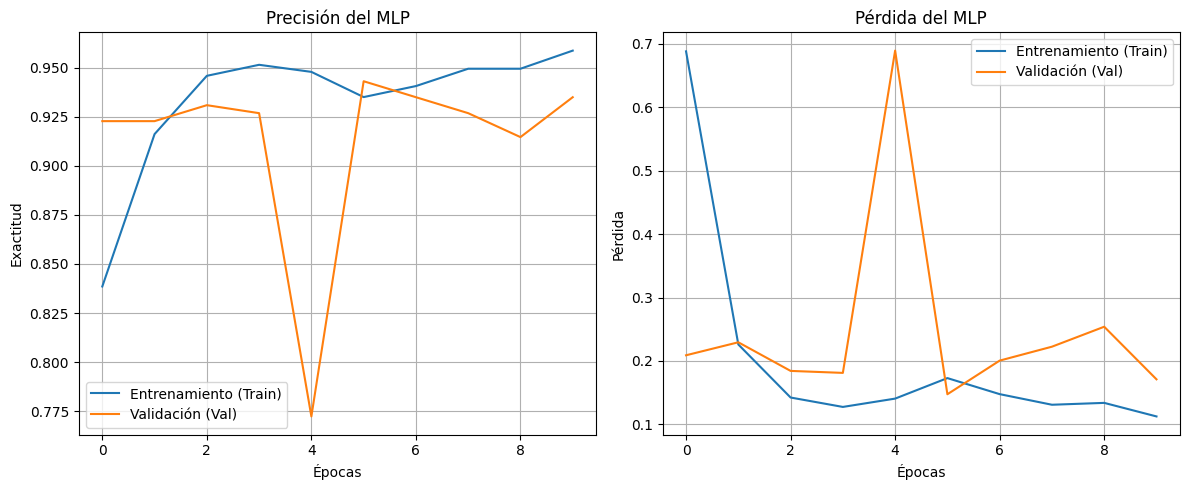

In [ ]:

# 9. Visualización de Resultados del MLP


import matplotlib.pyplot as plt

# Configuramos el tamaño de la ventana de visualización (12 pulgadas de ancho, 5 de alto)
plt.figure(figsize=(12, 5))

# --- 1. Gráfica de Precisión (Accuracy) ---
# 'subplot(filas, columnas, índice)' nos permite poner varias gráficas en una fila
plt.subplot(1, 2, 1)
# Graficamos la precisión obtenida durante el entrenamiento
plt.plot(history_mlp.history['accuracy'], label='Entrenamiento (Train)')
# Graficamos la precisión obtenida con los datos de validación (el examen del modelo)
plt.plot(history_mlp.history['val_accuracy'], label='Validación (Val)')
plt.title('Precisión del MLP') # Título de la gráfica
plt.xlabel('Épocas')           # Etiqueta del eje X (vueltas de entrenamiento)
plt.ylabel('Exactitud')        # Etiqueta del eje Y (porcentaje de aciertos)
plt.legend()                   # Muestra el cuadro que explica qué es cada línea
plt.grid(True)                 # Agrega una cuadrícula para facilitar la lectura

# --- 2. Gráfica de Pérdida (Loss) ---
plt.subplot(1, 2, 2)
# La pérdida mide el error cometido; entre más baja sea, mejor es el modelo
plt.plot(history_mlp.history['loss'], label='Entrenamiento (Train)')
plt.plot(history_mlp.history['val_loss'], label='Validación (Val)')
plt.title('Pérdida del MLP')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# 'tight_layout' ajusta automáticamente el espacio entre gráficas para que no se encimen
plt.tight_layout()
# Muestra la figura final en pantalla
plt.show()

imagenes

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


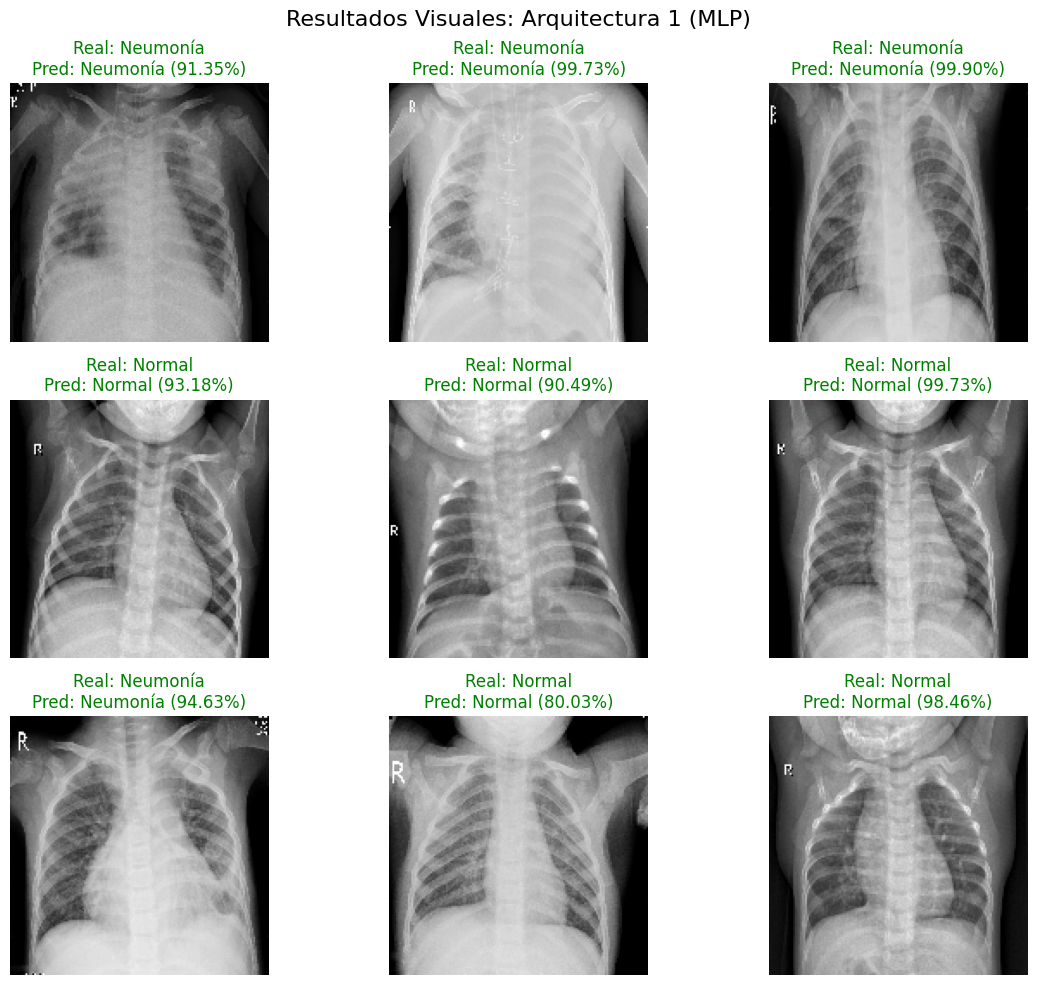

In [ ]:

# 10. Inferencia Visual y Verificación de Resultados

import matplotlib.pyplot as plt
import numpy as np

# 1. Obtenemos un lote (batch) de imágenes y sus etiquetas reales del generador de validación
# 'next' extrae el siguiente paquete de 32 imágenes para probar el modelo
x_val, y_val = next(validation_generator)

# 2. El modelo realiza las predicciones sobre este lote
preds_mlp = model_mlp.predict(x_val)

# Configuramos el lienzo para mostrar 9 ejemplos (matriz de 3x3)
plt.figure(figsize=(12, 10))
plt.suptitle("Resultados Visuales: Arquitectura 1 (MLP)", fontsize=16)

for i in range(9):
    # Creamos una cuadrícula de 3 filas por 3 columnas
    plt.subplot(3, 3, i + 1)

    # Mostramos la radiografía. 'reshape' asegura que la imagen tenga la forma 150x150
    plt.imshow(x_val[i].reshape(150, 150), cmap='gray')

    # Convertimos las etiquetas numéricas (0, 1) a texto legible
    real = "Neumonía" if y_val[i] == 1 else "Normal"

    # Aplicamos el umbral de decisión: > 0.5 es clase positiva (Neumonía)
    pred = "Neumonía" if preds_mlp[i] > 0.5 else "Normal"

    # Calculamos la confianza: si predijo Neumonía usamos el valor directo,
    # si predijo Normal usamos el complemento (1 - valor)
    conf = preds_mlp[i][0] if preds_mlp[i] > 0.5 else 1 - preds_mlp[i][0]

    # Lógica de color: Verde para aciertos, Rojo para errores
    color = 'green' if real == pred else 'red'

    # Mostramos el resultado sobre la imagen con el porcentaje de confianza
    plt.title(f"Real: {real}\nPred: {pred} ({conf:.2%})", color=color)

    # Ocultamos los ejes (coordenadas de píxeles) para que se vea más limpio
    plt.axis('off')

plt.tight_layout()
plt.show()

Arquitectura 2: CNN (Red Convolucional Simple)

In [ ]:

# 11. Definición y Entrenamiento de la Arquitectura 2 (CNN)


model_cnn = models.Sequential([
    # --- Bloque 1 ---
    # La convolución aplica 32 filtros de 3x3 para extraer características iniciales.
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 1)),
    # Reduce la dimensionalidad, manteniendo los rasgos más fuertes y ahorrando memoria.
    layers.MaxPooling2D((2, 2)),

    # --- Bloque 2 ---
    # Aumentamos a 64 filtros para detectar patrones de textura más detallados.
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # --- Bloque 3 ---
    # 128 filtros para capturar la complejidad de las opacidades en las radiografías.
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # --- Bloque Clasificador ---
    # Convierte los mapas de características 2D en un vector para la parte final.
    layers.Flatten(),
    # Una capa densa de 128 neuronas para razonar sobre las características extraídas.
    layers.Dense(128, activation='relu'),
    # Salida única con sigmoide para determinar la probabilidad de enfermedad.
    layers.Dense(1, activation='sigmoid')
])

# Configuración del entrenamiento (idéntica al MLP para que la comparativa sea justa)
model_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Entrenando CNN Simple (Arquitectura 2)...")

# Entrenamiento de la red convolucional
history_cnn = model_cnn.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando CNN Simple (Arquitectura 2)...
Epoch 1/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.9232 - loss: 0.1937 - val_accuracy: 0.9675 - val_loss: 0.1135
Epoch 2/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.9675 - loss: 0.0927 - val_accuracy: 0.9756 - val_loss: 0.0866
Epoch 3/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 245s 2s/step - accuracy: 0.9789 - loss: 0.0622 - val_accuracy: 0.9593 - val_loss: 0.1023
Epoch 4/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 245s 2s/step - accuracy: 0.9751 - loss: 0.0695 - val_accuracy: 0.9431 - val_loss: 0.1378
Epoch 5/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 252s 2s/step - accuracy: 0.9781 - loss: 0.0577 - val_accuracy: 0.9593 - val_loss: 0.1185
Epoch 6/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.9844 - loss: 0.0424 - val_accuracy: 0.9837 - val_loss: 0.0481
Epoch 7/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 245s 2s/step - accuracy: 0.9900 - loss: 0.0249 - val_accuracy: 0.9431 - val_loss: 0.1429
Epoch 8/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 245s 2s/step - 

Grafica

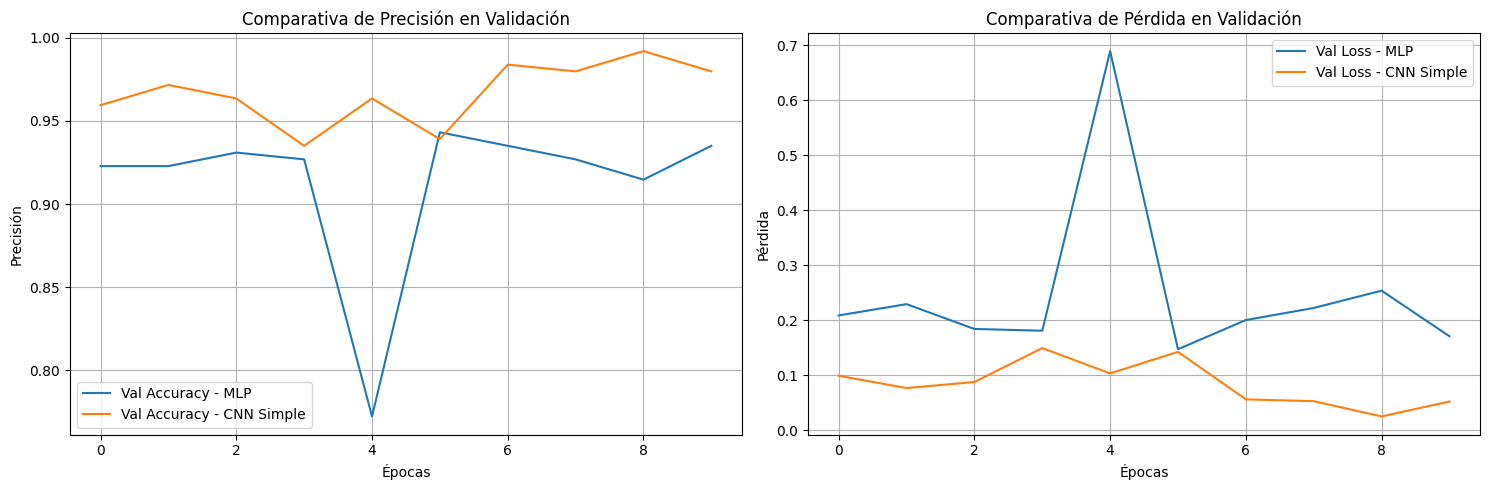

In [ ]:

# 12. Comparativa de Rendimiento entre Arquitecturas

# Invocamos la función de comparación visual.
# Pasamos como primer argumento una lista con los historiales de entrenamiento
# y como segundo argumento los nombres de las etiquetas para la leyenda.
graficar_comparativa(
    [history_mlp, history_cnn], # Lista de objetos 'history' (contienen accuracy y loss)
    ['MLP', 'CNN Simple']       # Nombres que aparecerán en las gráficas para identificar cada línea
)


Imagenes

Entrenando CNN Simple (Arquitectura 2)...
Epoch 1/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - accuracy: 0.8965 - loss: 0.2593 - val_accuracy: 0.9472 - val_loss: 0.1410
Epoch 2/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 245s 2s/step - accuracy: 0.9641 - loss: 0.0964 - val_accuracy: 0.9431 - val_loss: 0.1637
Epoch 3/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.9657 - loss: 0.0852 - val_accuracy: 0.9634 - val_loss: 0.1095
Epoch 4/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - accuracy: 0.9755 - loss: 0.0692 - val_accuracy: 0.9878 - val_loss: 0.0647
Epoch 5/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.9830 - loss: 0.0471 - val_accuracy: 0.9390 - val_loss: 0.1750
Epoch 6/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.9838 - loss: 0.0458 - val_accuracy: 0.9797 - val_loss: 0.0673
Epoch 7/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/step - accuracy: 0.9868 - loss: 0.0351 - val_accuracy: 0.9715 - val_loss: 0.0950
Epoch 8/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - 

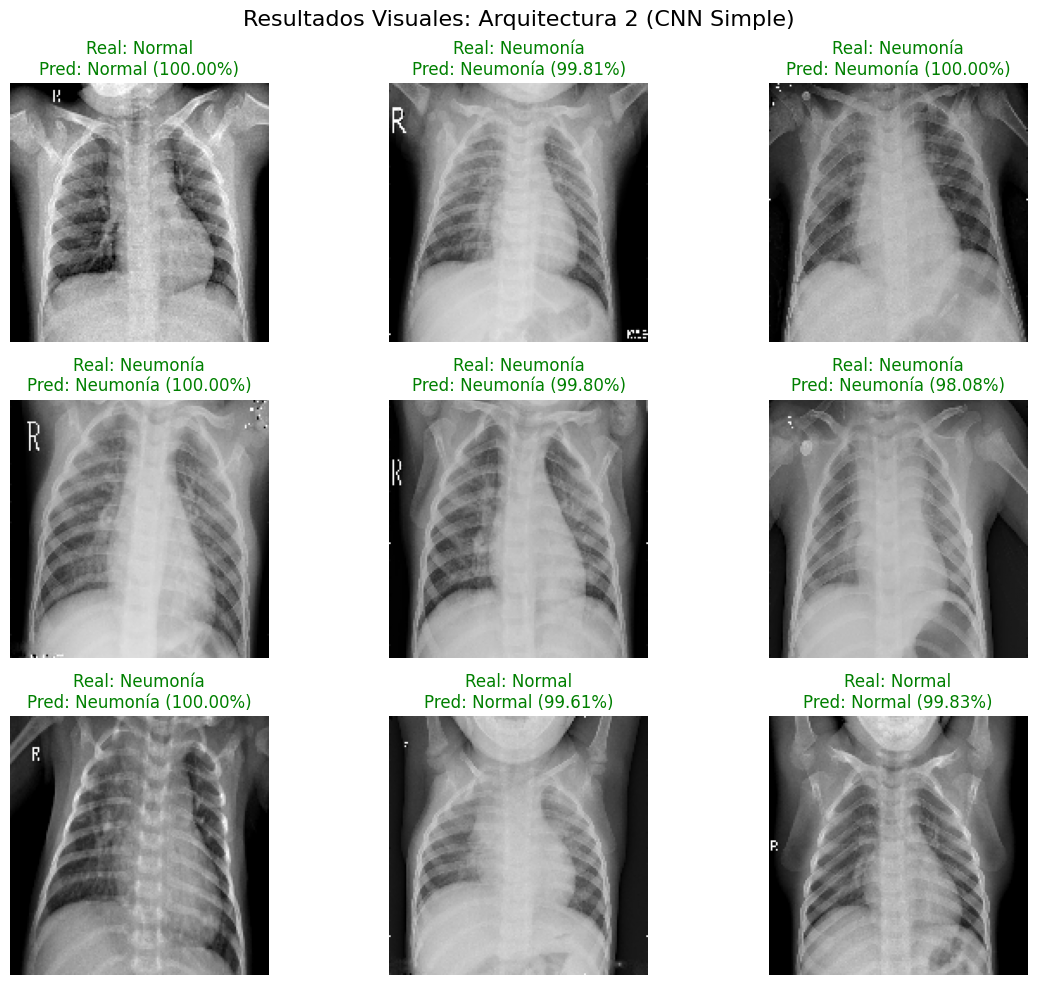

In [ ]:

# 13. Definición, Entrenamiento y Verificación Visual de la CNN

# 1. Definición del Modelo CNN (Convolutional Neural Network)
model_cnn = models.Sequential([
    # Capa 1: 32 filtros de 3x3. Detecta rasgos primitivos como bordes y sombras.
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 1)),
    layers.MaxPooling2D((2, 2)), # Reduce el tamaño a la mitad (75x75)

    # Capa 2: 64 filtros. Comienza a identificar formas anatómicas más complejas.
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)), # Reduce el tamaño (37x37 aprox)

    # Capa 3: 128 filtros. Captura patrones específicos de infecciones pulmonares.
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)), # Reduce el tamaño (18x18 aprox)

    # Clasificación: 'Flatten' convierte los mapas de rasgos finales en un vector plano.
    layers.Flatten(),
    # Capa densa con 128 neuronas para la toma de decisiones lógica.
    layers.Dense(128, activation='relu'),
    # Sigmoide para obtener la probabilidad final de clase (0=Sano, 1=Neumonía).
    layers.Dense(1, activation='sigmoid')
])

# 2. Compilación del Modelo
model_cnn.compile(
    optimizer='adam',                # Ajuste de pesos eficiente
    loss='binary_crossentropy',      # Error para clasificación binaria
    metrics=['accuracy']             # Métrica principal: Exactitud
)

# 3. Entrenamiento del Modelo
print("Entrenando CNN Simple (Arquitectura 2)...")
history_cnn = model_cnn.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# --- VISUALIZACIÓN DE IMÁGENES (Inferencia Directa) ---
import matplotlib.pyplot as plt
import numpy as np

# Tomamos una muestra de datos de validación que el modelo no ha usado para ajustar pesos
x_val, y_val = next(validation_generator)
# Obtenemos las predicciones (valores entre 0 y 1)
preds_cnn = model_cnn.predict(x_val)

plt.figure(figsize=(12, 10))
plt.suptitle("Resultados Visuales: Arquitectura 2 (CNN Simple)", fontsize=16)

for i in range(9):
    plt.subplot(3, 3, i + 1)
    # Mostramos la imagen original (150x150)
    plt.imshow(x_val[i].reshape(150, 150), cmap='gray')

    # Mapeo de etiquetas numéricas a texto
    real = "Neumonía" if y_val[i] == 1 else "Normal"
    pred = "Neumonía" if preds_cnn[i] > 0.5 else "Normal"

    # Cálculo de confianza: si predice >0.5 es Neumonía, si no, calculamos qué tan cerca está de 0
    conf = preds_cnn[i][0] if preds_cnn[i] > 0.5 else 1 - preds_cnn[i][0]

    # Verde si acertó, rojo si falló
    color = 'green' if real == pred else 'red'
    plt.title(f"Real: {real}\nPred: {pred} ({conf:.2%})", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

Arquitectura 3: CNN Robusta

In [ ]:

# 14. Arquitectura 3: CNN con Aumento de Datos y Regularización (Dropout)

# 1. Configuramos el Aumento de Datos (Data Augmentation)
# Solo se aplica al set de entrenamiento para que el modelo vea variaciones.
train_datagen_augmented = ImageDataGenerator(
    rescale=1./255,         # Normalización (siempre necesaria)
    rotation_range=15,      # Gira la imagen aleatoriamente hasta 15 grados
    width_shift_range=0.1,  # Mueve la imagen horizontalmente (10%)
    height_shift_range=0.1, # Mueve la imagen verticalmente (10%)
    zoom_range=0.2,         # Acerca o aleja la imagen aleatoriamente
    fill_mode='nearest'     # Estrategia para rellenar píxeles vacíos tras transformar
)

# El generador de validación NO usa aumentos, pues queremos evaluar con datos reales.
train_generator_aug = train_datagen_augmented.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    color_mode='grayscale'
)

# 2. Definición de la arquitectura con Capa de Dropout
model_reg = models.Sequential([
    # Capas Convolucionales (mantienen la estructura de la Arquitectura 2)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    # --- TÉCNICA DE REGULARIZACIÓN ---
    # Dropout(0.5) desconecta aleatoriamente la mitad de las neuronas en cada iteración.
    # Esto evita el sobreajuste (overfitting) y mejora la precisión en datos nuevos.
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

# Compilación
model_reg.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Entrenando la Arquitectura 3 (CNN con Dropout y Augmentation)...")

# Entrenamiento usando el generador con imágenes aumentadas
history_reg = model_reg.fit(
    train_generator_aug,
    epochs=10,
    validation_data=validation_generator
)

Found 4986 images belonging to 2 classes.
Entrenando la Arquitectura 3 (CNN con Dropout y Augmentation)...
Epoch 1/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.7768 - loss: 0.4753 - val_accuracy: 0.7846 - val_loss: 0.5179
Epoch 2/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 272s 2s/step - accuracy: 0.8406 - loss: 0.3169 - val_accuracy: 0.9146 - val_loss: 0.2552
Epoch 3/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.8845 - loss: 0.2859 - val_accuracy: 0.9187 - val_loss: 0.2062
Epoch 4/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - accuracy: 0.8983 - loss: 0.2419 - val_accuracy: 0.9350 - val_loss: 0.1847
Epoch 5/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 252s 2s/step - accuracy: 0.9091 - loss: 0.2199 - val_accuracy: 0.9472 - val_loss: 0.1411
Epoch 6/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.9170 - loss: 0.1998 - val_accuracy: 0.9593 - val_loss: 0.1355
Epoch 7/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - accuracy: 0.9138 - loss: 0.2163 - val_accuracy: 0.9472 - val_los

Grafica


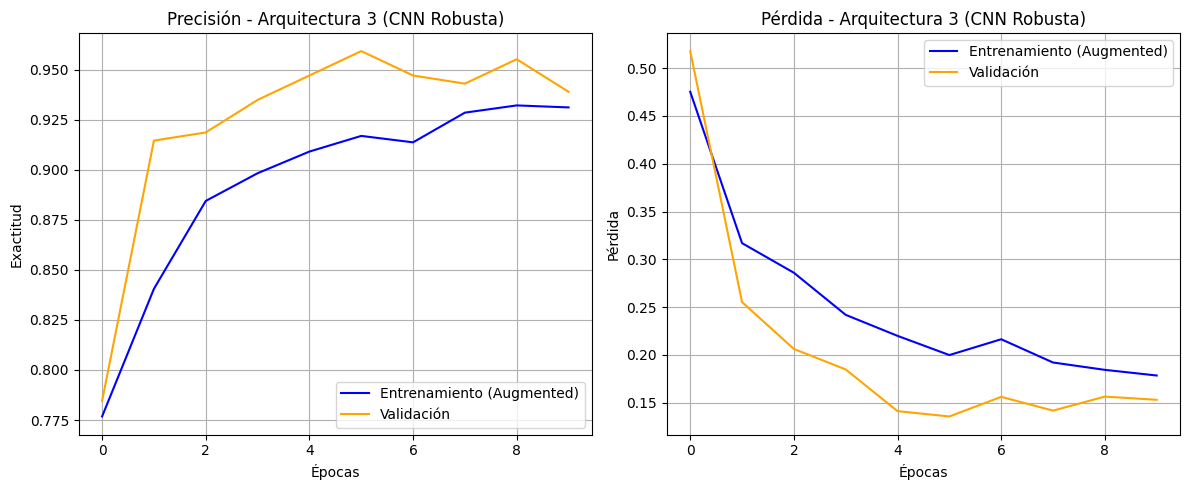

In [ ]:

# 15. Evaluación Visual de la Arquitectura 3 (CNN Robusta)

import matplotlib.pyplot as plt

# Configuramos el tamaño de la figura para mostrar dos paneles
plt.figure(figsize=(12, 5))

# --- 1. Panel de Precisión (Accuracy) ---
plt.subplot(1, 2, 1)
# Graficamos el entrenamiento con aumento de datos (línea azul)
plt.plot(history_reg.history['accuracy'], label='Entrenamiento (Augmented)', color='blue')
# Graficamos la validación con datos reales (línea naranja)
plt.plot(history_reg.history['val_accuracy'], label='Validación', color='orange')
plt.title('Precisión - Arquitectura 3 (CNN Robusta)')
plt.xlabel('Épocas')
plt.ylabel('Exactitud')
plt.legend()
plt.grid(True) # Cuadrícula para medir con precisión los puntos de convergencia

# --- 2. Panel de Pérdida (Loss) ---
plt.subplot(1, 2, 2)
# Una pérdida que baja de forma constante en ambas líneas indica un modelo sano
plt.plot(history_reg.history['loss'], label='Entrenamiento (Augmented)', color='blue')
plt.plot(history_reg.history['val_loss'], label='Validación', color='orange')
plt.title('Pérdida - Arquitectura 3 (CNN Robusta)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Ajuste automático de márgenes para evitar encimamiento de títulos
plt.tight_layout()
# Despliegue de las gráficas
plt.show()

imagenes

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step


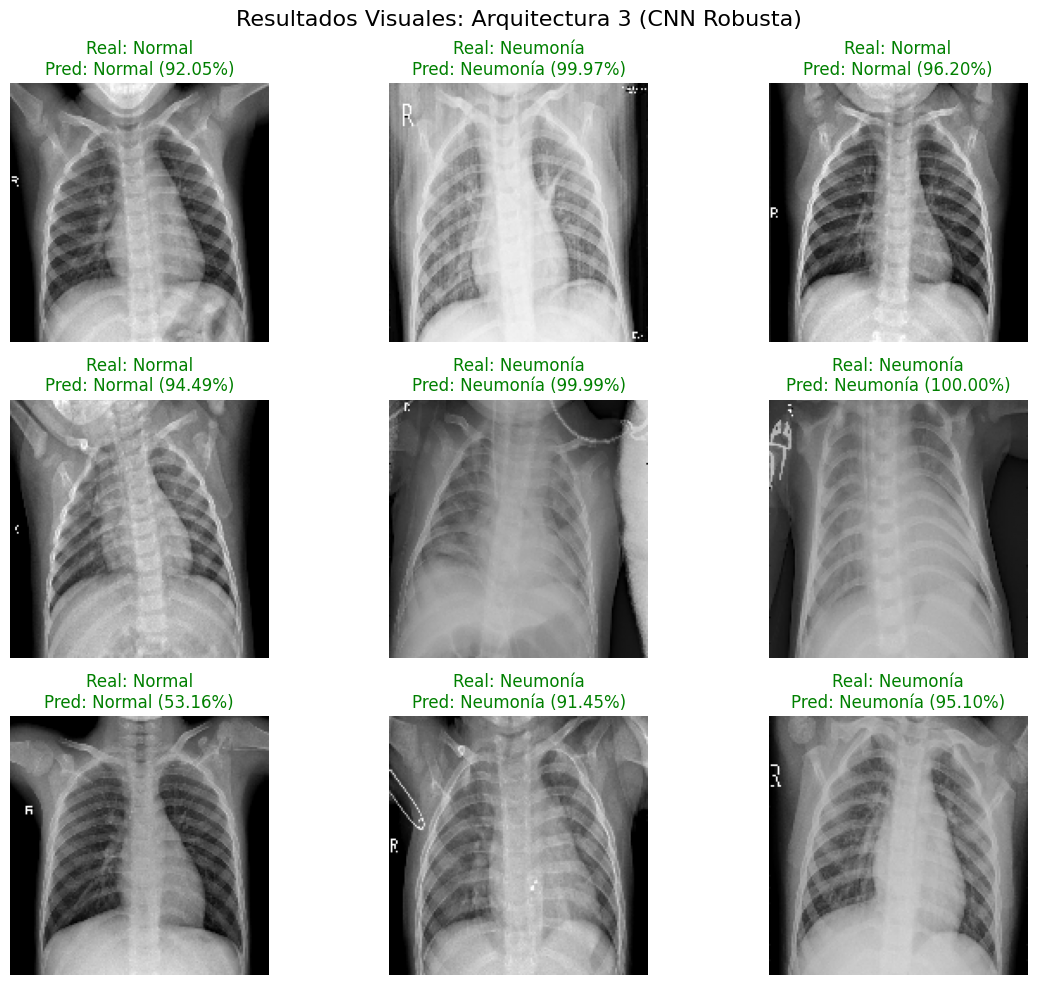

In [ ]:

# 16. Inferencia Visual: Verificación de la Arquitectura 3 (CNN Robusta)


import numpy as np

# 1. Extracción de datos de prueba:
# 'next' toma el siguiente grupo (lote) de imágenes del generador de validación.
x_val, y_val = next(validation_generator)

# 2. El modelo robusto (con Dropout) realiza sus predicciones:
preds_reg = model_reg.predict(x_val)

# Configuración del lienzo para mostrar 9 ejemplos
plt.figure(figsize=(12, 10))
plt.suptitle("Resultados Visuales: Arquitectura 3 (CNN Robusta)", fontsize=16)

for i in range(9):
    plt.subplot(3, 3, i + 1)

    # 'reshape' elimina la dimensión del canal (1) para que matplotlib la grafique correctamente
    plt.imshow(x_val[i].reshape(150, 150), cmap='gray')

    # Mapeo de valores numéricos a etiquetas de texto médico
    real = "Neumonía" if y_val[i] == 1 else "Normal"

    # Umbral de decisión estándar (0.5) para determinar la clase predicha
    pred = "Neumonía" if preds_reg[i] > 0.5 else "Normal"

    # Cálculo de la confianza:
    # Representa qué tan seguro está el modelo de su elección (de 0% a 100%)
    conf = preds_reg[i][0] if preds_reg[i] > 0.5 else 1 - preds_reg[i][0]

    # Semáforo visual: Verde para predicción correcta, Rojo para error
    color = 'green' if real == pred else 'red'

    # Se imprime el diagnóstico real, el predicho y la confianza
    plt.title(f"Real: {real}\nPred: {pred} ({conf:.2%})", color=color)

    # Quitamos los ejes para centrar la atención en la imagen médica
    plt.axis('off')

# Ajuste fino del diseño para que los títulos no se traslapen
plt.tight_layout()
plt.show()

Arquitectura 4: Transfer Learning con VGG16.

Configurar Generadores para VGG16

In [ ]:

# 17. Configuración de Datos para Transfer Learning (VGG16)


from tensorflow.keras.applications.vgg16 import preprocess_input

# 1. Definición del Preprocesamiento Específico:
# 'preprocessing_function=preprocess_input' asegura que las imágenes se
# transformen exactamente como lo requieren las capas internas de VGG16.
vgg_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# 2. Generador de Entrenamiento para VGG16:
train_gen_vgg = vgg_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    # IMPORTANTE: VGG16 requiere 3 canales (RGB). El generador convertirá
    # automáticamente las radiografías de escala de grises a 3 canales.
    color_mode='rgb'
)

# 3. Generador de Validación para VGG16:
val_gen_vgg = vgg_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    color_mode='rgb'
)

Found 4986 images belonging to 2 classes.
Found 246 images belonging to 2 classes.


Construir y Entrenar la Arquitectura 4

In [ ]:

# 18. Arquitectura 4: Transfer Learning con VGG16

from tensorflow.keras.applications import VGG16

# 1. Cargar la base de VGG16 pre-entrenada:
# - weights='imagenet': Carga los pesos aprendidos en el concurso ImageNet.
# - include_top=False: Quitamos las capas finales (las que clasificaban perros, autos, etc.)
#   para poner nuestras propias capas médicas.
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# 2. Congelamos la base:
# Esto es CRUCIAL. Evita que el optimizador altere los filtros ya aprendidos de VGG16.
base_model.trainable = False

# 3. Construcción del modelo personalizado:
model_vgg = models.Sequential([
    base_model,           # El "extractor" de características profesional
    layers.Flatten(),     # Convertimos los mapas de rasgos en un vector
    layers.Dense(256, activation='relu'), # Capa densa para interpretar los rasgos de VGG
    layers.Dropout(0.5),  # Regularización para evitar que memorice las fotos
    layers.Dense(1, activation='sigmoid') # Clasificación binaria final
])

# 4. Compilación:
# Usamos 'adam' y 'binary_crossentropy' para mantener la consistencia con los otros modelos.
model_vgg.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Entrenando Arquitectura 4: VGG16 (Transfer Learning)...")

# 5. Entrenamiento:
# Nota que usamos 'train_gen_vgg'
history_vgg = model_vgg.fit(
    train_gen_vgg,
    epochs=10,
    validation_data=val_gen_vgg
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Entrenando Arquitectura 4: VGG16 (Transfer Learning)...
Epoch 1/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 1243s 8s/step - accuracy: 0.9130 - loss: 1.2676 - val_accuracy: 0.9837 - val_loss: 0.0653
Epoch 2/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 1244s 8s/step - accuracy: 0.9623 - loss: 0.1000 - val_accuracy: 0.9593 - val_loss: 0.0817
Epoch 3/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 1248s 8s/step - accuracy: 0.9713 - loss: 0.0800 - val_accuracy: 0.9675 - val_loss: 0.0696
Epoch 4/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 1245s 8s/step - accuracy: 0.9755 - loss: 0.0646 - val_accuracy: 0.9756 - val_loss: 0.0419
Epoch 5/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 1250s 8s/step - accuracy: 0.9781 - loss: 0.0614 - val_accuracy: 0.9878 - val_loss: 0.0327
Epoch 6/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 1232s 8s/step - accuracy: 0.9787 - loss: 0.0505 - val_accuracy: 0.9878 - val_loss: 0.0521
Epoch 7/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 1227s 8s/step - accuracy: 0.9783 - loss: 0.0579 - val_accuracy: 0.9431 - 

Gráficas y Visualización de la Arquitectura 4

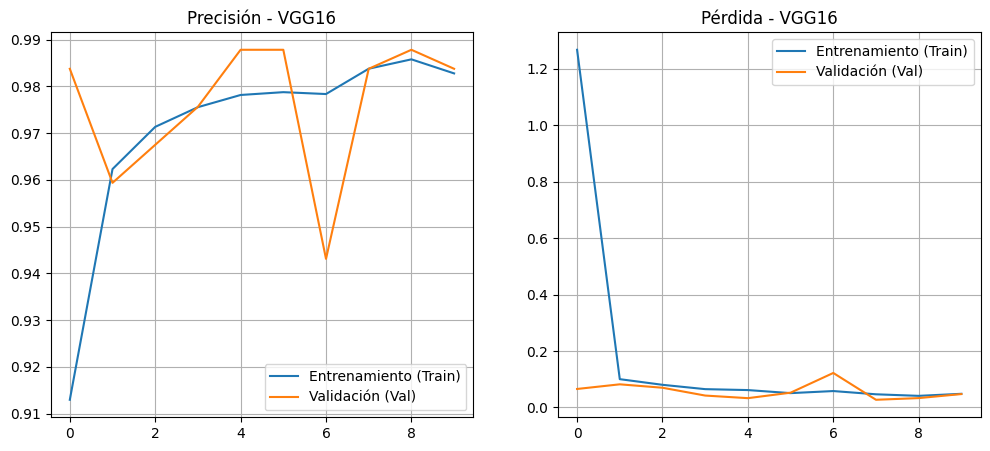

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


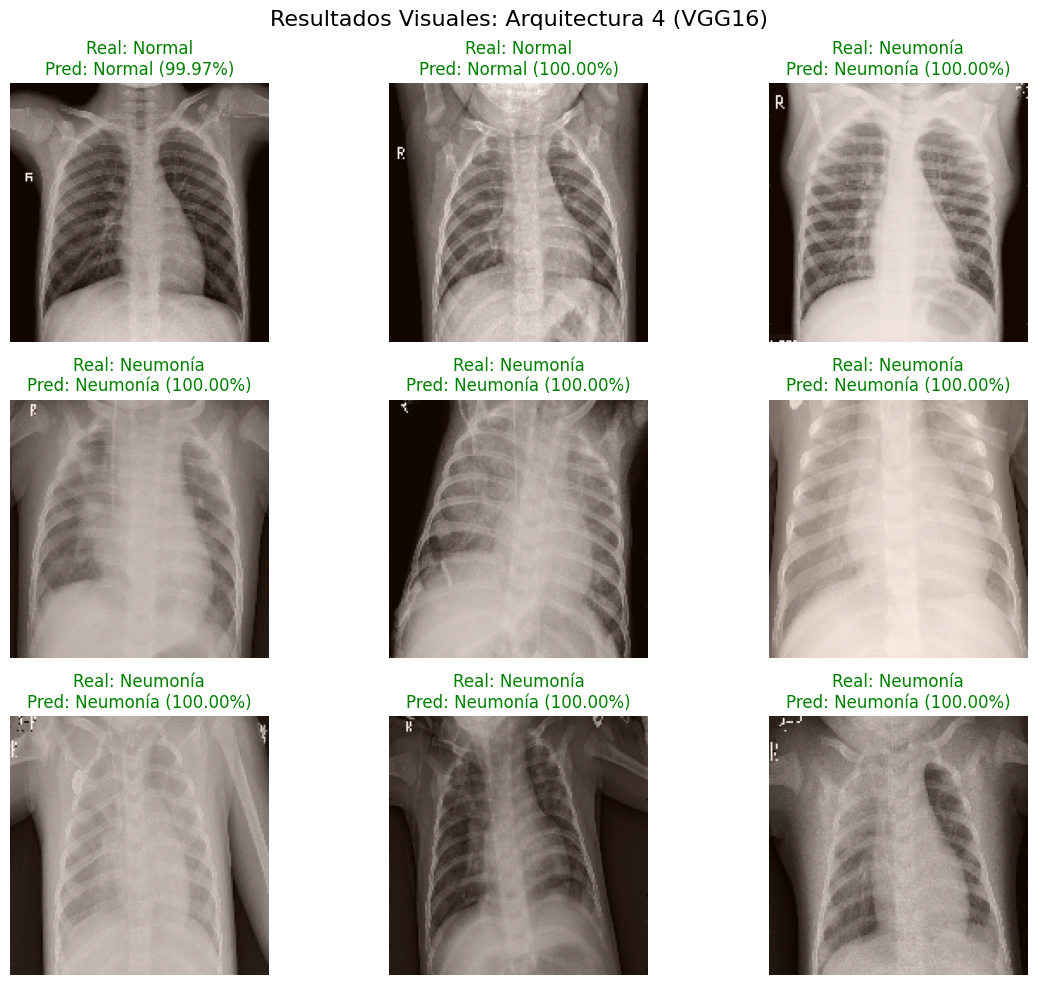

In [ ]:

# 19. Evaluación y Visualización de Resultados: VGG16


import matplotlib.pyplot as plt

# --- PARTE 1: Gráficas de Rendimiento ---
plt.figure(figsize=(12, 5))

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history_vgg.history['accuracy'], label='Entrenamiento (Train)')
plt.plot(history_vgg.history['val_accuracy'], label='Validación (Val)')
plt.title('Precisión - VGG16')
plt.legend()
plt.grid(True)

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(history_vgg.history['loss'], label='Entrenamiento (Train)')
plt.plot(history_vgg.history['val_loss'], label='Validación (Val)')
plt.title('Pérdida - VGG16')
plt.legend()
plt.grid(True)
plt.show()

# --- PARTE 2: Inferencia Visual con Re-normalización ---
# Obtenemos un lote de imágenes preprocesadas para VGG
x_vgg, y_vgg = next(val_gen_vgg)
preds_vgg = model_vgg.predict(x_vgg)

plt.figure(figsize=(12, 10))
plt.suptitle("Resultados Visuales: Arquitectura 4 (VGG16)", fontsize=16)

for i in range(9):
    plt.subplot(3, 3, i + 1)

    # RE-NORMALIZACIÓN:
    # VGG16 resta la media de ImageNet, lo que altera los valores de los píxeles.
    # Esta fórmula ajusta los valores al rango [0, 1] solo para poder ver la imagen.
    img_disp = (x_vgg[i] - x_vgg[i].min()) / (x_vgg[i].max() - x_vgg[i].min())
    plt.imshow(img_disp)

    # Lógica de etiquetas y predicción
    real = "Neumonía" if y_vgg[i] == 1 else "Normal"
    pred = "Neumonía" if preds_vgg[i] > 0.5 else "Normal"

    # Cálculo de confianza según la probabilidad obtenida
    conf = preds_vgg[i][0] if preds_vgg[i] > 0.5 else 1 - preds_vgg[i][0]

    # Semáforo de acierto (Verde/Rojo)
    color = 'green' if real == pred else 'red'
    plt.title(f"Real: {real}\nPred: {pred} ({conf:.2%})", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

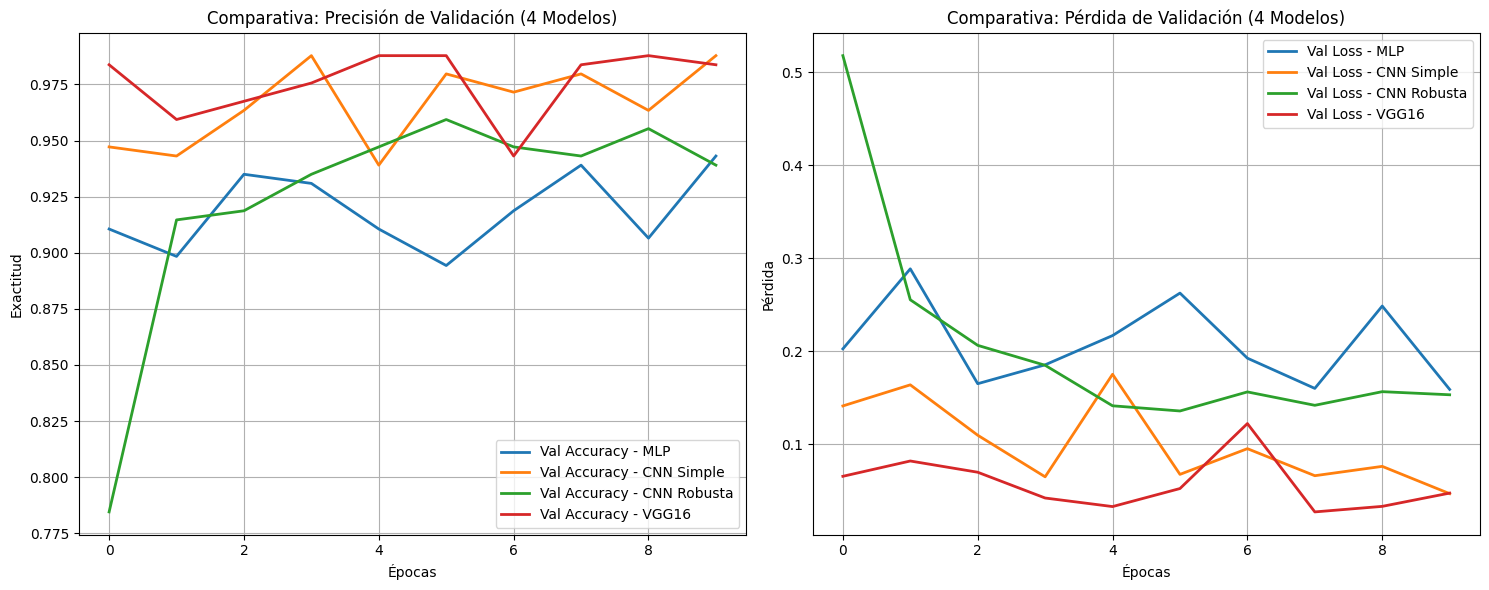

In [ ]:
import matplotlib.pyplot as plt

def graficar_comparativa_final(histories, names):
    plt.figure(figsize=(15, 6))

    # 1. Comparativa de Precisión (Accuracy)
    plt.subplot(1, 2, 1)
    for i in range(len(histories)):
        plt.plot(histories[i].history['val_accuracy'], label=f'Val Accuracy - {names[i]}', linewidth=2)

    plt.title('Comparativa: Precisión de Validación (4 Modelos)')
    plt.xlabel('Épocas')
    plt.ylabel('Exactitud')
    plt.legend()
    plt.grid(True)

    # 2. Comparativa de Pérdida (Loss)
    plt.subplot(1, 2, 2)
    for i in range(len(histories)):
        plt.plot(histories[i].history['val_loss'], label=f'Val Loss - {names[i]}', linewidth=2)

    plt.title('Comparativa: Pérdida de Validación (4 Modelos)')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Ejecutamos la comparativa con las 4 historias que guardamos
graficar_comparativa_final(
    [history_mlp, history_cnn, history_reg, history_vgg],
    ['MLP', 'CNN Simple', 'CNN Robusta', 'VGG16']
)